In [2]:
from qiskit import ClassicalRegister, QuantumCircuit, QuantumRegister
import numpy as np
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import SamplerV2 as Sampler
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit.visualization import plot_histogram
from qiskit.result import marginal_counts
import matplotlib.pyplot as plt
import datetime

/home/lukas/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


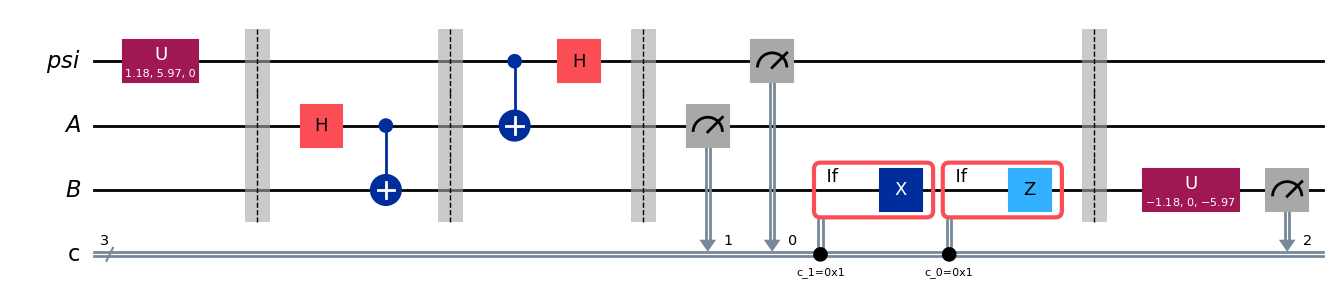

In [3]:
# Define registers and circuit
unknown_state = QuantumRegister(1, "psi")
Alice = QuantumRegister(1, "A")
Bob = QuantumRegister(1, "B")
cr = ClassicalRegister(3, "c")
qc = QuantumCircuit(unknown_state, Alice, Bob, cr)
 
# We create the unknown state by randomly generating the angles theta and varphi and applying it to unitary gate u
np.random.seed(42)
theta = np.random.uniform(0.0, 1.0) * np.pi
varphi = np.random.uniform(0.0, 2.0) * np.pi
qc.u(theta, varphi, 0.0, unknown_state)
qc.barrier()

# We entangle Alice's and Bob's qubits
qc.h(Alice)
qc.cx(Alice, Bob)
qc.barrier()
 
# Now we apply the CNOT and H gates to Alice's qubits
qc.cx(unknown_state, Alice)
qc.h(unknown_state)
qc.barrier()
 
# Now Alice measures her qubits
qc.measure(Alice, cr[1])
qc.measure(unknown_state, cr[0])
 
# We apply the necessary gates to Bob's qubit based on Alice's measurement results
with qc.if_test((cr[1], 1)):
    qc.x(Bob)
with qc.if_test((cr[0], 1)):
    qc.z(Bob)
qc.barrier()
 
# Finally, we apply the inverse of u to Bob's qubit and measure for verification of the teleportation
qc.u(theta, varphi, 0.0, Bob).inverse()
qc.measure(Bob, cr[2])
 
qc.draw(output="mpl")

In [ ]:
service = QiskitRuntimeService()
backend = service.backend("ibm_torino")
pm = generate_preset_pass_manager(target=backend.target, optimization_level=3)
qc_isa = pm.run(qc)
sampler = Sampler(mode=backend)

job = sampler.run([qc_isa])
res = job.result()
counts = res[0].data.c.get_counts()

Probability of 0 on qubit 2: 0.8088


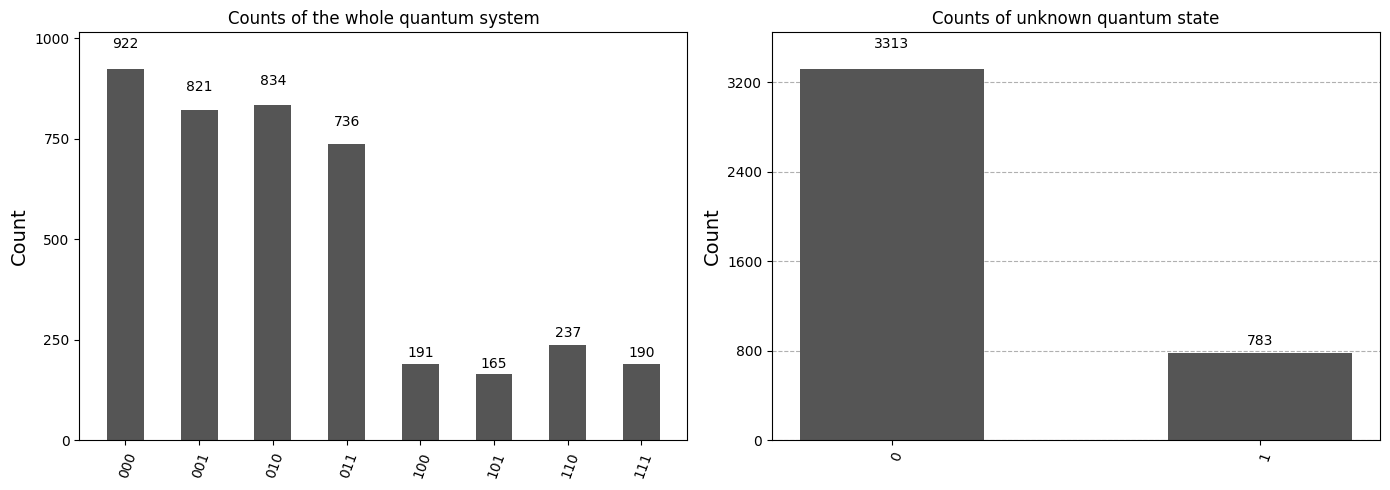

In [7]:
filtered_statistics = marginal_counts(counts, [2])
total_shots = sum(filtered_statistics.values())
prob_0 = filtered_statistics.get('0', 0) / total_shots
print(f"Probability of 0 on qubit 2: {prob_0:.4f}")

timestamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
#filename = f"counts_{timestamp}.txt"

#with open(filename, 'w') as f:
#    for key, value in counts.items():
#       f.write(f'{key}: {value}\n')
#    f.write("\nMarginal Counts (Qubit 2):\n")
#    for key, value in filtered_statistics.items():
#        f.write(f'{key}: {value}\n')
#    f.write(f"\nProbability of 0 on qubit 2: {prob_0:.4f}\n")
#    f.write(f"Backend used: {backend.name}\n")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Plot full counts
plot_histogram(counts, ax=ax1, color='#555555')
ax1.set_title("Counts of the whole quantum system")  # set title directly

# Plot marginal counts
plot_histogram(filtered_statistics, ax=ax2, color='#555555')
ax2.set_title("Counts of unknown quantum state")  # set title directly

plt.tight_layout()
plt.show()